# 项目：可视化帕默群岛企鹅数据

## 分析目标

此数据分析报告的目的是对帕默群岛上企鹅样本的相关变量进行可视化，从而探索和分析种类、性别、所在岛屿等因素，与企鹅的身体属性，包括体重、嘴峰长度和深度、鳍的长度，之间的关系。

## 简介

原始数据`Penguins.csv`包括334个收集自南极洲帕尔默群岛的3个岛屿上的企鹅样本，以及企鹅相关属性数据，包括种类名、所在岛、嘴峰长度、嘴峰深度、鳍长度、体重、性别。

`Penguins.csv`每列的含义如下：
- species：企鹅的种类
- island：企鹅所在岛
- culmen_length_mm：企鹅嘴峰的长度（单位为毫米）
- culmen_depth_mm：企鹅嘴峰的深度（单位为毫米）
- flipper_length_mm：企鹅鳍的长度（单位为毫米）
- body_mass_g：企鹅体重（单位为克）
- sex：企鹅性别

### 读取数据

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
original_data = pd.read_csv("penguins.csv")
original_data.head()

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


### 评估和清理数据

##### 为了区分开经过清理的数据和原始的数据，创建新的变量cleaned_data，让它为original_data复制出的副本。之后的清理步骤都将被运用在cleaned_data上。

In [3]:
cleaned_data = original_data.copy()

#### 数据整齐度

In [4]:
cleaned_data.head(10)

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,MALE
6,Adelie,Torgersen,38.9,17.8,181.0,3625.0,FEMALE
7,Adelie,Torgersen,39.2,19.6,195.0,4675.0,MALE
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0,NaN
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,NaN


In [5]:
cleaned_data.tail(10)

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
334,Gentoo,Biscoe,46.2,14.1,217.0,4375.0,FEMALE
335,Gentoo,Biscoe,55.1,16.0,230.0,5850.0,MALE
336,Gentoo,Biscoe,44.5,15.7,217.0,4875.0,.
337,Gentoo,Biscoe,48.8,16.2,222.0,6000.0,MALE
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,FEMALE
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,FEMALE
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,MALE
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,FEMALE
343,Gentoo,Biscoe,49.9,16.1,213.0,5400.0,MALE


In [6]:
cleaned_data.sample(10)

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
324,Gentoo,Biscoe,47.3,13.8,216.0,4725.0,NaN
39,Adelie,Dream,39.8,19.1,184.0,4650.0,MALE
87,Adelie,Dream,36.9,18.6,189.0,3500.0,FEMALE
28,Adelie,Biscoe,37.9,18.6,172.0,3150.0,FEMALE
332,Gentoo,Biscoe,43.5,15.2,213.0,4650.0,FEMALE
40,Adelie,Dream,36.5,18.0,182.0,3150.0,FEMALE
203,Chinstrap,Dream,51.4,19.0,201.0,3950.0,MALE
319,Gentoo,Biscoe,51.1,16.5,225.0,5250.0,MALE
198,Chinstrap,Dream,50.1,17.9,190.0,3400.0,FEMALE
7,Adelie,Torgersen,39.2,19.6,195.0,4675.0,MALE


##### 从头部和尾部的10行数据来看，数据符合“每个变量为一列，每个观察值为一行，每种类型的观察单位为一个表格”，因此不存在结构性问题。尽管发现了NaN值，但属于内容上的问题，此处暂时不管

#### 数据干净度

##### 通过`info`，对数据内容进行大致了解。

In [7]:
cleaned_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   culmen_length_mm   342 non-null    float64
 3   culmen_depth_mm    342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                334 non-null    str    
dtypes: float64(4), str(3)
memory usage: 18.9 KB


##### 从输出结果可以看出，cleaned_data数据共有344条观察值，其中culmen_length_mm、culmen_depth_mm、flipper_length_mm、body_mass_g变量只有342条，sex只有334条，存在缺失值，将在后续进行评估和清理。
数据类型方面，通过简介已知species（企鹅种类）sex（企鹅性别）、island（企鹅所在岛）都是分类数据，因此可以把数据类型都转换为Category，先做这一步。

In [8]:
cleaned_data['species'] = cleaned_data['species'].astype('category')
cleaned_data['island'] = cleaned_data['island'].astype('category')
cleaned_data['sex'] = cleaned_data['sex'].astype('category')

##### 通过`info`方法检查结果

In [9]:
cleaned_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   species            344 non-null    category
 1   island             344 non-null    category
 2   culmen_length_mm   342 non-null    float64 
 3   culmen_depth_mm    342 non-null    float64 
 4   flipper_length_mm  342 non-null    float64 
 5   body_mass_g        342 non-null    float64 
 6   sex                334 non-null    category
dtypes: category(3), float64(4)
memory usage: 12.0 KB


##### species、island、sex的数据类型成功被转换为category

#### 处理缺失数据

##### 现在处理检查数据整齐度时发现的缺失值，含缺失值列中除了sex外，其他含缺失值列都缺了2条，因此先把这些缺失值提取出来，观察异同点

In [10]:
cleaned_data.query('culmen_length_mm.isna()')

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN


In [11]:
cleaned_data.query('culmen_depth_mm.isna()')

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN


In [12]:
cleaned_data.query('flipper_length_mm.isna()')

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN


In [13]:
cleaned_data.query('flipper_length_mm.isna()')

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN


##### 提取结果可以看到索引为3和339的观察值，除了种类和所属岛屿外，所有变量都为空，无法为探索企鹅身体属性相关因素提供价值，因此可以把这两行直接删除。

In [14]:
cleaned_data.drop(3,inplace = True)
cleaned_data.drop(339,inplace = True)

In [15]:
cleaned_data.query('sex.isna()')

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0,NaN
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,NaN
10,Adelie,Torgersen,37.8,17.1,186.0,3300.0,NaN
11,Adelie,Torgersen,37.8,17.3,180.0,3700.0,NaN
47,Adelie,Dream,37.5,18.9,179.0,2975.0,NaN
246,Gentoo,Biscoe,44.5,14.3,216.0,4100.0,NaN
286,Gentoo,Biscoe,46.2,14.4,214.0,4650.0,NaN
324,Gentoo,Biscoe,47.3,13.8,216.0,4725.0,NaN


##### 缺失性别变量的观察值具备其它数据，仍然可以为分析提供价值。由于Pandas以及Matplotlib、Seaborn会自动忽略缺失值，可以保留这些行。

#### 处理重复数据

##### 根据数据变量的含义以及内容来看，允许变量重复，我们不需要对此数据检查是否存在重复值。

#### 处理不一致数据

##### 企鹅的类别、岛屿、性别都有可能存在不一致数据，因此每一项都要检查

In [16]:
cleaned_data['species'].value_counts()

species
Adelie       151
Gentoo       123
Chinstrap     68
Name: count, dtype: int64

##### 此项无异常

In [17]:
cleaned_data['island'].value_counts()

island
Biscoe       167
Dream        124
Torgersen     51
Name: count, dtype: int64

##### 此项无异常

In [18]:
cleaned_data['sex'].value_counts()

sex
MALE      168
FEMALE    165
.           1
Name: count, dtype: int64

##### 此项发现性别中出现一个性别为.的数据，为不一致数据，由于不知道它的性别，而性别不影响后续数据分析结果，因此把他替换为NaN值

In [19]:
cleaned_data['sex'] = cleaned_data['sex'].replace('.',np.nan)

##### 检查替换结果

In [20]:
cleaned_data['sex'].value_counts()

sex
MALE      168
FEMALE    165
.           0
Name: count, dtype: int64

##### 结果发现，.虽然替换成功，但仍然被统计数目，要将这个效果移除

In [21]:
cleaned_data['sex'] = cleaned_data['sex'].cat.remove_unused_categories()
cleaned_data['sex'].value_counts()

sex
MALE      168
FEMALE    165
Name: count, dtype: int64

##### 从输出结果看来，.的统计信息成功去除

#### 处理无效或错误数据

In [22]:
cleaned_data.describe()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


##### 未发现脱离现实意义的数值，到此数据已清洗干净

### **数据可视化**

##### 先设置一个喜欢的色盘

In [23]:
sns.set_palette('pastel')

In [24]:
cleaned_data

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,MALE
...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,FEMALE
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,FEMALE
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,MALE
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,FEMALE


#### **先看一下企鹅种类占比**

<function matplotlib.pyplot.show(close=None, block=None)>

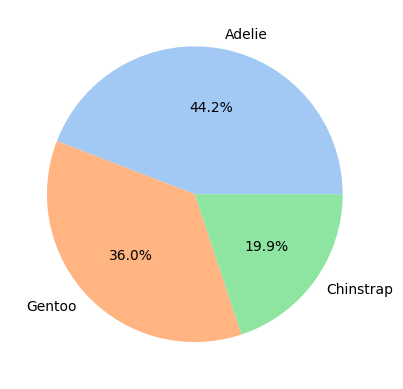

In [25]:
species_counts = cleaned_data['species'].value_counts()
plt.pie(species_counts,autopct='%.1f%%',labels=species_counts.index)
plt.show()

##### 样本中Adelie这个种类的企鹅占比最大，Gentoo种类的占比次之，Chinstrap的占比最小。

#### **企鹅所属岛屿占比**

<function matplotlib.pyplot.show(close=None, block=None)>

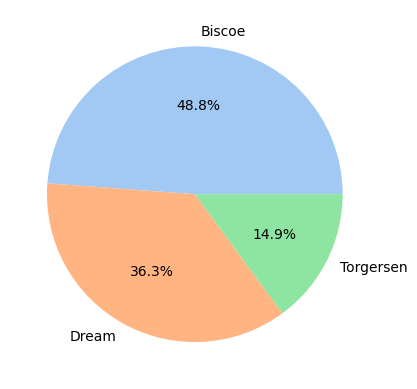

In [26]:
island_counts = cleaned_data['island'].value_counts()
plt.pie(island_counts,autopct='%.1f%%',labels=island_counts.index)
plt.show()

##### 样本中一半左右的企鹅样本都来自Biscoe岛屿，占比最大，其次是Dream岛屿，来自Torgersen岛屿的样本最少。

#### **企鹅性别占比**

<function matplotlib.pyplot.show(close=None, block=None)>

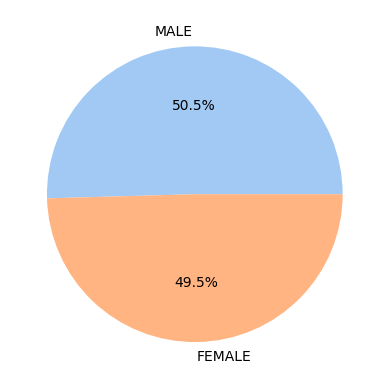

In [27]:
sex_counts = cleaned_data['sex'].value_counts()
plt.pie(sex_counts,autopct='%.1f%%',labels=sex_counts.index)
plt.show()

##### 样本企鹅的性别占比持平，符合随机抽样。

#### **不同岛上的企鹅种类数量**

<function matplotlib.pyplot.show(close=None, block=None)>

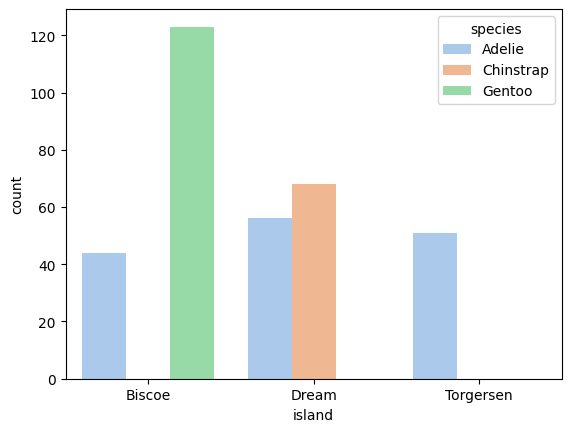

In [28]:
sns.countplot(cleaned_data,x='island',hue='species')
plt.show()

##### 从上图可以看出，Adelie种类的企鹅样本在Biscoe、Dream、Torgersen这三个岛上都有，而Chinstrap种类只在Dream岛上才有，Gentoo只在Biscoe岛上才有。

#### **不同岛上的企鹅性别分布**

<function matplotlib.pyplot.show(close=None, block=None)>

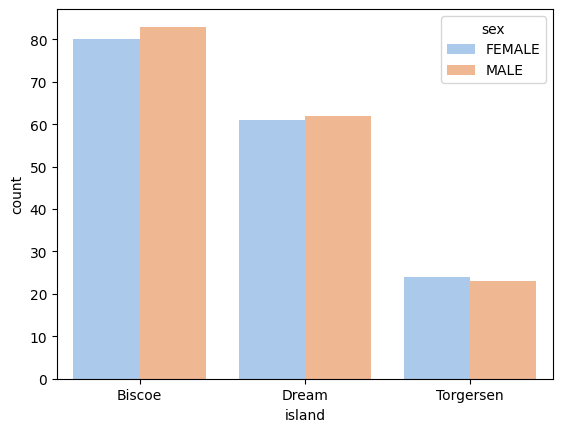

In [29]:
sns.countplot(cleaned_data,x='island',hue='sex')
plt.show()

#### **查看数值之间的相关性**

<function matplotlib.pyplot.show(close=None, block=None)>

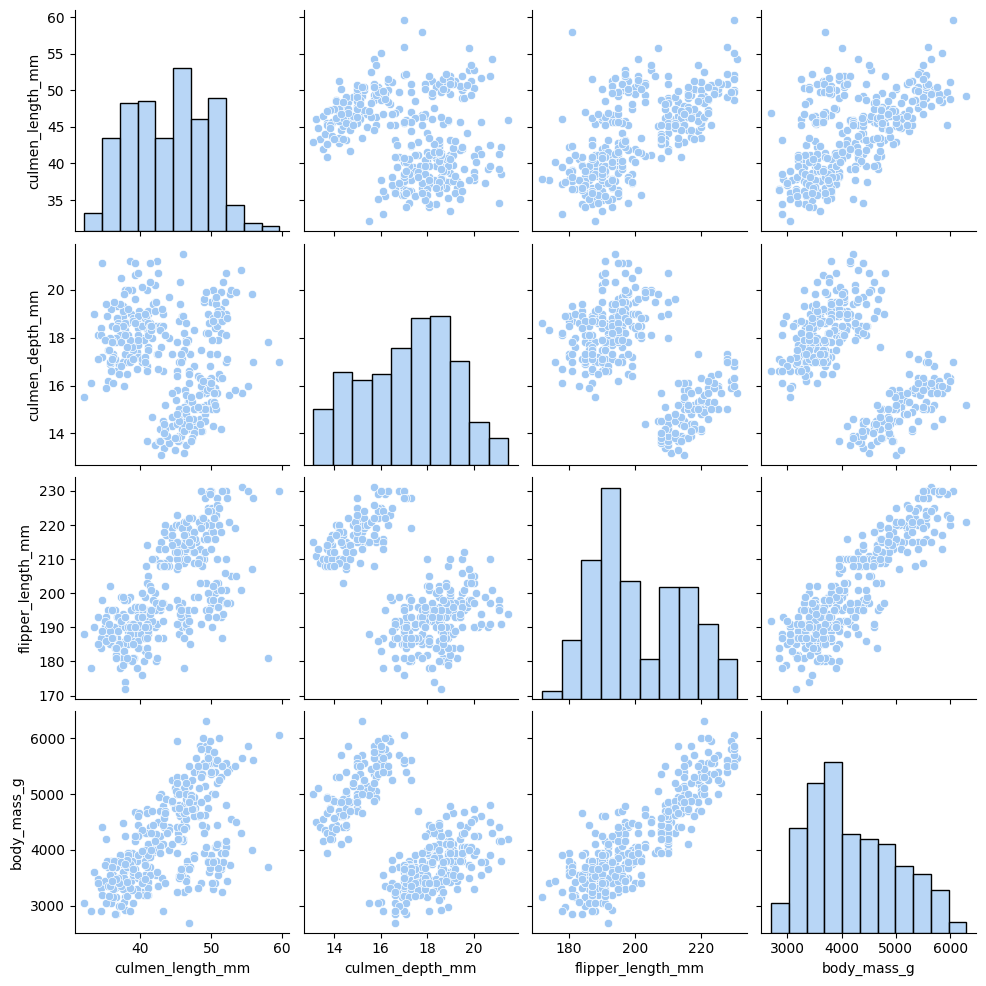

In [30]:
sns.pairplot(cleaned_data)
plt.show()

##### 从直方图来看，企鹅样本的嘴峰长度、嘴峰深度、鳍长度、体重的分布不是正态分布。一方面说明，这里面可能包含了多组存在差异的样本数据，另一方面也说明样本数不够大。另外可以在散点图中看出明显的多个集群，可能与某些因素有关，比如企鹅种类、性别，因此可以对对比进行进一步的分类。

#### **根据种类查看数值之间的相关关系**

<function matplotlib.pyplot.show(close=None, block=None)>

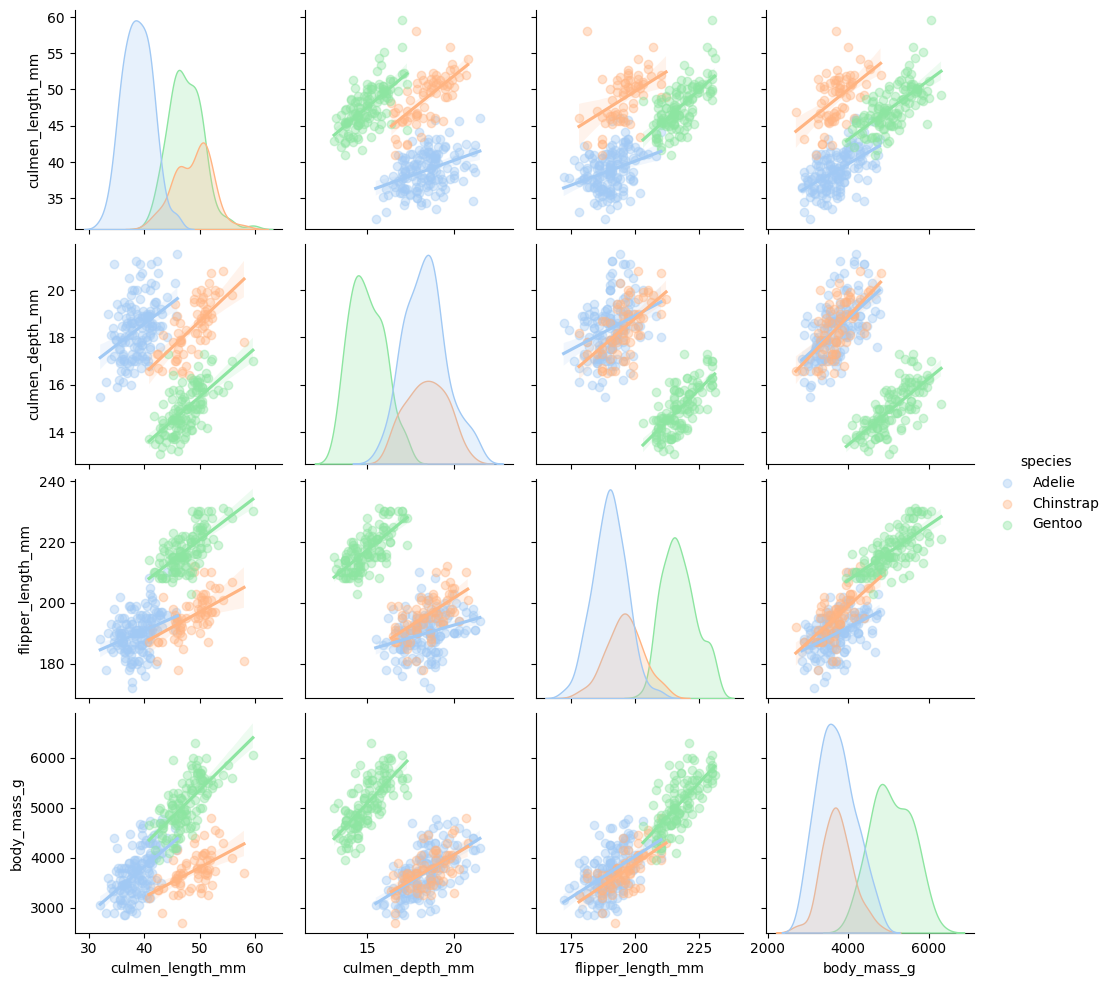

In [31]:
sns.pairplot(cleaned_data,hue='species',kind='reg',plot_kws={'scatter_kws':{'alpha':0.4}})
plt.show()

##### 同一种类的企鹅样本数据，在散点图上基本都聚在一起，说明同一种类的企鹅在嘴峰长度、嘴峰深度、鳍长度、体重之间关系上，存在相似性。这些发现有利于我们根据体重、鳍长等数值推测企鹅种类，也可以根据企鹅种类推测体重、鳍长等数值。散点图结合线性回归线来看，同类企鹅的属性数据之间均呈线性正比，即嘴峰越长，嘴峰越深，鳍越长，体重越重，嘴峰越短，嘴峰越浅，鳍越短，体重越轻。

从密度图的分布来看，可以得到以下关于样本的发现：

Chinstrap和Gentoo的嘴峰长度范围较为接近，而Adelie的嘴峰长度更短。
Adelie和Chinstrap的嘴峰深度范围较为接近，而Gentoo的嘴峰深度更短。
Adelie的鳍长度最短，Chinstrap中等，而Gentoo的鳍长度嘴长。
Adelie和Chinstrap的体重范围较为接近，而Gentoo的体重更大。
但不同种类的属性数值否存在统计显著性差异，仍然需要进行假设检验后才能得到结论。

#### **根据性别查看数值之间的相关关系**

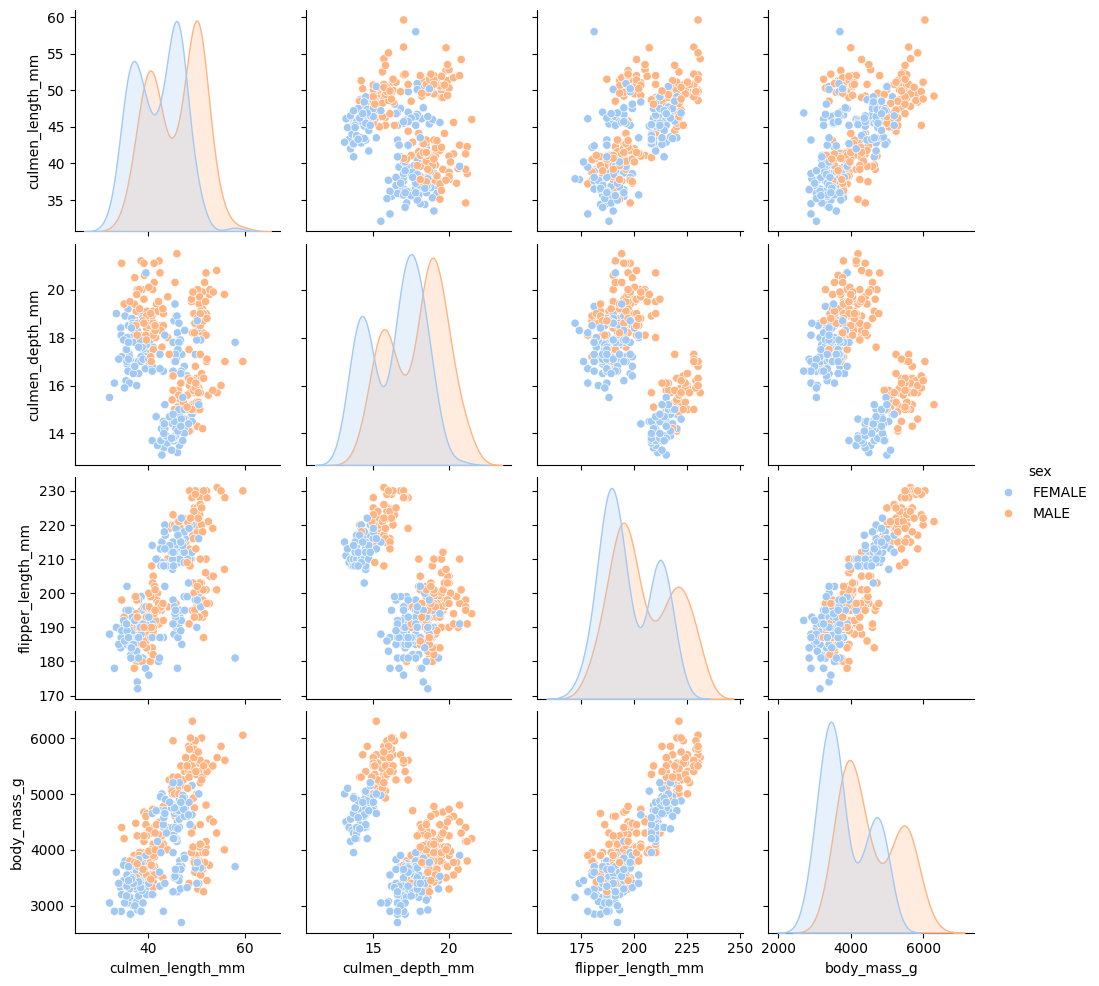

In [32]:
sns.pairplot(cleaned_data,hue='sex')
plt.show()

##### 根据性别划分后可以看出，样本中雄性企鹅在各项属性数值方面大于雌性企鹅。